# Customer Segmentation using K-Means Clustering

###  Objective:
Segment customers into distinct groups based on their purchasing behavior to enable targeted marketing strategies.

## 1. Problem Statement

Businesses often struggle to understand diverse customer behaviors. Without proper segmentation, marketing strategies become inefficient and less impactful.

This project aims to group customers into meaningful clusters based on their income and spending patterns using unsupervised learning techniques.

## 2. Business Objective

The goal of this project is to:

- Identify distinct customer segments
- Enable targeted marketing strategies
- Improve customer retention
- Increase overall revenue

###  Key Business Questions:
- Who are the high-value customers?
- Which customers need attention?
- Which segment can be targeted for promotions?

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wn

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [12]:
print(df.shape)
df.info()

(200, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [4]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

###  Dataset Overview:

- Dataset contains customer demographic and spending data
- No missing values observed
- Features include:
  - Age
  - Annual Income
  - Spending Score
- CustomerID is not useful for modeling

In [6]:
# Check missing values
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
# Drop unnecessary column
df.drop('CustomerID', axis=1, inplace=True)
df

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


- No missing values found
- CustomerID removed as it does not contribute to clustering

# Exploratory Data Analysis (EDA)

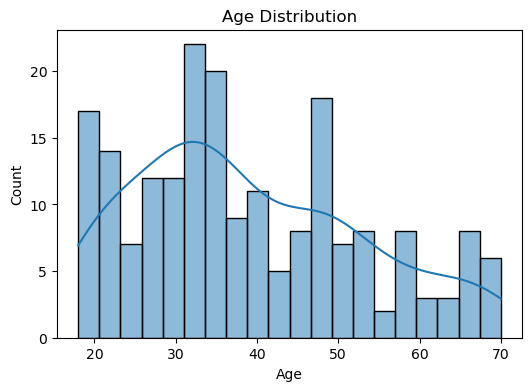

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'],bins = 20,kde =True)
plt.title("Age Distribution")
plt.show()

### Age Distribution Insights

- The customer base is skewed towards younger individuals, with most customers between 20–35 years.
- A noticeable secondary concentration appears around ages 45–50, indicating a potential mid-age segment.
- Very few customers fall below 20 or above 60.

### Business Implication:
- Marketing efforts should primarily target the 25–55 age range.
- Different strategies can be designed for younger vs. middle-aged customers.

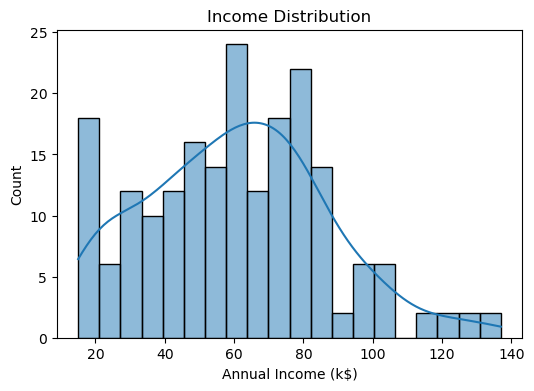

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df['Annual Income (k$)'],bins=20,kde= True)
plt.title("Income Distribution")
plt.show()

### Income Distribution Insights

- Income is fairly evenly distributed across a moderate range.
- No extreme skewness, suggesting a balanced mix of low, medium, and high-income customers.
- No significant outliers observed.

### Business Implication:
- The dataset supports meaningful segmentation based on income.
- Businesses can design tier-based offerings (budget, mid-range, premium).

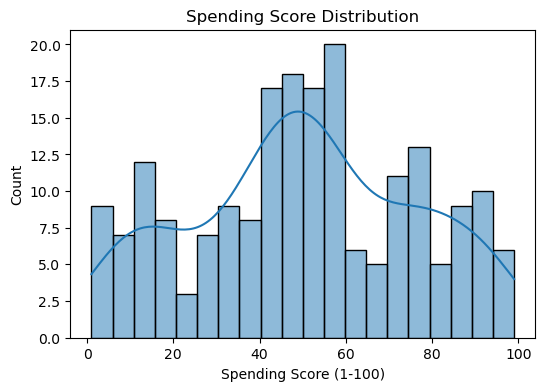

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df['Spending Score (1-100)'],bins=20,kde=True)
plt.title("Spending Score Distribution")
plt.show()

### Spending Score Insights

- Spending score is widely spread across the full range (1–100).
- Indicates strong variability in customer purchasing behavior.
- Presence of both high spenders and low spenders.

### Business Implication:
- Clear opportunity for behavioral segmentation.
- Enables identification of high-value vs. low-value customers.

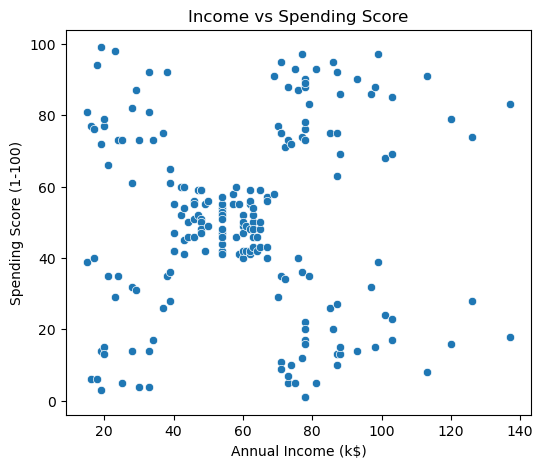

In [16]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    data=df
)
plt.title("Income vs Spending Score")
plt.show()

### Income vs Spending Score Insights

- Clear grouping patterns are visible, indicating natural clusters in the data.
- Customers can be broadly categorized into:
  - High Income, High Spending
  - High Income, Low Spending
  - Low Income, High Spending
  - Low Income, Low Spending

### Business Implication:
- High Income + High Spending → Premium customers (focus on retention)
- High Income + Low Spending → Untapped potential (target marketing)
- Low Income + High Spending → Risky segment
- Low Income + Low Spending → Low-value customers

This plot strongly justifies the use of K-Means clustering.

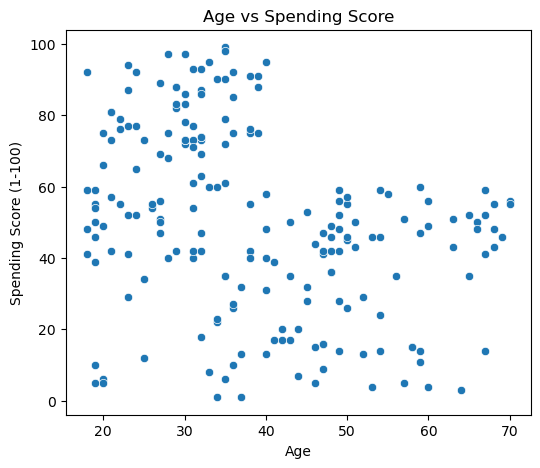

In [17]:
plt.figure(figsize=(6,5))
sns.scatterplot(
    x='Age', 
    y='Spending Score (1-100)', 
    data=df
)
plt.title("Age vs Spending Score")
plt.show()

### Age vs Spending Insights

- Younger customers tend to have higher spending scores.
- Older customers generally show lower spending behavior.

### Business Implication:
- Younger customers are more active spenders → target promotions
- Older customers may require different engagement strategies

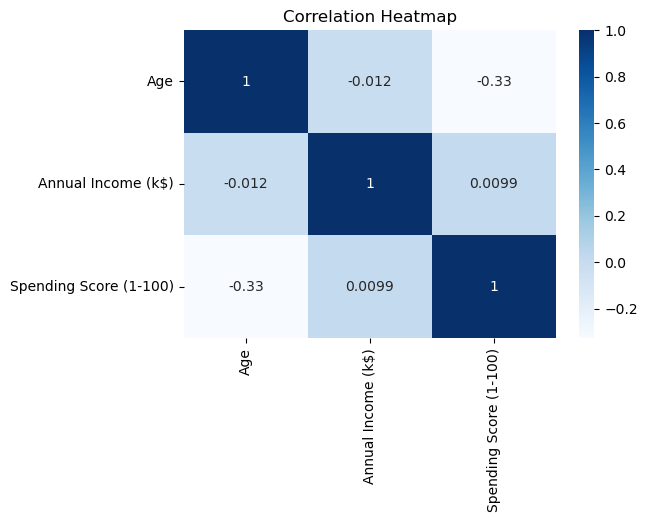

In [25]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

### Correlation Insights

- Weak correlation between most features.
- Income and Spending Score are not strongly correlated.
- Age shows slight negative relation with spending.

### Business Implication:
- Features provide independent information → good for clustering

## Feature Selection

In [27]:
features = df[['Annual Income (k$)','Spending Score (1-100)']]

### Feature Selection

- Selected Annual Income and Spending Score for clustering
- These features show clear separation in EDA
- Helps in meaningful and interpretable segmentation

## Feature Scaling

In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

### Feature Scaling

- K-Means relies on distance calculations
- Scaling ensures all features contribute equally
- Prevents dominance of high-value features like income

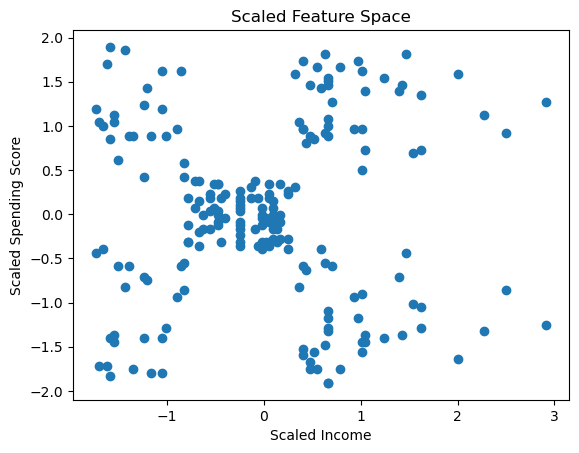

In [29]:
## Scaled Data Visualization
plt.scatter(X_scaled[:,0], X_scaled[:,1])
plt.title("Scaled Feature Space")
plt.xlabel("Scaled Income")
plt.ylabel("Scaled Spending Score")
plt.show()

- Data is now normalized around 0
- Ensures fair clustering without bias

## Elbow Method

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

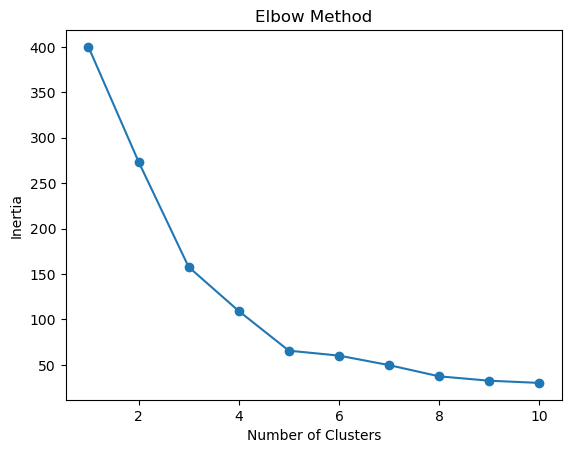

In [34]:
inertia = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state = 42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,11),inertia,marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

### Elbow Method Insight

- Inertia decreases as number of clusters increases
- Sharp bend observed at k = 5
- After this point, improvement reduces significantly

 Optimal K selected = 5

## K-Means Clustering

In [35]:
kmeans = KMeans(n_clusters = 5,random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## Cluster Visualization

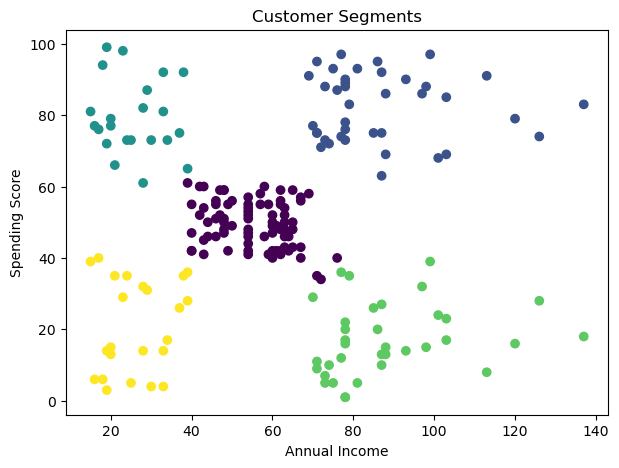

In [36]:
plt.figure(figsize=(7,5))

plt.scatter(
    df['Annual Income (k$)'], 
    df['Spending Score (1-100)'], 
    c=df['Cluster']
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

## Cluster Interpretation

In [39]:
df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


##  Customer Segmentation Insights

###  Cluster 1: Premium Customers
- High income, high spending
- Young and highly engaged
- Action: Loyalty programs, exclusive offers

###  Cluster 2: High-Spending Low-Income Customers
- Low income but high spending
- Likely impulsive or trend-driven
- Action: Discounts, budget-focused marketing

###  Cluster 3: Wealthy but Low-Spending Customers
- High income, low spending
- Untapped potential segment
- Action: Personalized campaigns, premium awareness

###  Cluster 4: Low-Value Customers
- Low income, low spending
- Least profitable group
- Action: Minimal marketing focus

###  Cluster 0: Average Customers
- Moderate income and spending
- Stable but not highly profitable
- Action: General promotions, upselling strategies

**The segmentation reveals that not all high-income customers are high spenders, highlighting the importance of targeted marketing strategies rather than assuming spending behavior based on income alone.**

##  Conclusion

In this project, customer segmentation was performed using K-Means clustering based on Annual Income and Spending Score.

The analysis identified 5 distinct customer segments with clearly different behavioral patterns. These segments reveal that customers with similar income levels can exhibit very different spending behaviors, highlighting the importance of behavioral segmentation over simple demographic assumptions.

Key findings include:
- A high-value segment of young, high-income, high-spending customers
- A group of high-income but low-spending customers representing untapped potential
- A segment of low-income but high-spending customers indicating impulsive behavior
- Clearly defined low-value and average customer groups

Overall, the clustering approach successfully uncovered meaningful patterns that can support data-driven decision-making in marketing and customer relationship management.

##  Business Recommendations

Based on the identified customer segments, the following strategies are recommended:

### 1. Focus on Premium Customers (High Income, High Spending)
- Offer loyalty programs and exclusive benefits
- Provide early access to premium products
- Enhance customer retention strategies

### 2. Target High-Income, Low-Spending Customers
- Use personalized marketing campaigns
- Promote premium product awareness
- Offer tailored incentives to increase engagement

### 3. Manage High-Spending, Low-Income Customers
- Provide budget-friendly offers and discounts
- Avoid over-targeting expensive products
- Monitor long-term profitability

### 4. Optimize Resources for Low-Value Customers
- Reduce marketing spend on low-income, low-spending group
- Focus on cost-efficient engagement strategies

### 5. Engage Average Customers
- Use general promotions and upselling techniques
- Encourage transition into higher-value segments

###  Strategic Impact:
- Improved marketing efficiency
- Better customer targeting
- Increased revenue potential

In [42]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df['Cluster'])

print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


##  Silhouette Score Evaluation

The silhouette score for the clustering model is **0.55**, which indicates a reasonably good clustering structure.

- The clusters are well-separated and distinct
- Data points are appropriately grouped within their clusters
- There is minimal overlap between clusters

### Interpretation:
- A score above 0.5 suggests effective segmentation
- The chosen value of K = 5 provides a good balance between cluster separation and cohesion

- Overall, the clustering model performs well and produces meaningful customer segments.
- This validates the selection of K=5 as an optimal number of clusters, supporting both visual and quantitative evaluation.”